# **Install Libraries**

In [1]:
!pip install -q torch
!pip install -q sentencepiece

# **Scraping Teori Relativitas**

In [2]:
import requests
from bs4 import BeautifulSoup
import re
import os
import time

def scrape_wikipedia(url):
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'
    }

    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()

        soup = BeautifulSoup(response.content, 'html.parser')

        # Hapus elemen yang sering menyebabkan whitespace atau noise di artikel sains
        for element in soup(['style', 'script', 'math', 'annotation']):
            element.decompose()

        content_div = soup.find('div', class_='mw-parser-output')
        if content_div:
            paragraphs = content_div.find_all('p')
        else:
            paragraphs = soup.find_all('p')

        # Membersihkan setiap paragraf dan membuang yang kosong
        cleaned_paragraphs = []
        for p in paragraphs:
            text_content = p.get_text().strip()
            if text_content:
                # Membersihkan referensi sitasi seperti [1], [2], [a]
                text_content = re.sub(r'\[.*?\]', '', text_content)
                cleaned_paragraphs.append(text_content)

        # Menggabungkan dengan satu newline dan membersihkan spasi berlebih antar baris
        full_text = "\n".join(cleaned_paragraphs)
        full_text = re.sub(r'\n\s*\n+', '\n\n', full_text) # Pastikan maksimal 2 newline

        return full_text

    except requests.exceptions.RequestException as e:
        print(f"  [Error] Gagal mengambil data dari {url}: {e}")
        return ""

urls = [
    "https://id.wikipedia.org/wiki/Teori_relativitas",
    "https://id.wikipedia.org/wiki/Prinsip_relativitas",
    "https://id.wikipedia.org/wiki/Sejarah_relativitas_umum",
    "https://id.wikipedia.org/wiki/Pengantar_relativitas_umum",
    "https://id.wikipedia.org/wiki/Relativitas_umum",
    "https://id.wikipedia.org/wiki/Relativitas_khusus",
    "https://id.wikipedia.org/wiki/Kerangka_acuan_inersia",
    "https://id.wikipedia.org/wiki/Prinsip_ekuivalensi",
    "https://id.wikipedia.org/wiki/Ekuivalensi_massa%E2%80%93energi",
    "https://id.wikipedia.org/wiki/Persamaan_medan_Einstein"
]

print("Mengambil data dari Wikipedia...")
corpus = ""
for url in urls:
    print(f"Scraping: {url}")
    scraped_content = scrape_wikipedia(url)
    if scraped_content:
        corpus += scraped_content + "\n\n"
    time.sleep(2) # Delay 2 seconds to respect Wikipedia policy

# Membersihkan sisa-sisa spasi berlebih di seluruh corpus
corpus = re.sub(r'\n{3,}', '\n\n', corpus).strip()

word_count = len(corpus.split())
print(f"\nScraping selesai. Total kata yang didapat: {word_count} kata.")

file_path = "corpus.txt"
if word_count > 0:
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(corpus)
    print(f"Corpus berhasil disimpan di: {os.path.abspath(file_path)}")
else:
    print("Gagal membuat corpus.")

Mengambil data dari Wikipedia...
Scraping: https://id.wikipedia.org/wiki/Teori_relativitas
Scraping: https://id.wikipedia.org/wiki/Prinsip_relativitas
Scraping: https://id.wikipedia.org/wiki/Sejarah_relativitas_umum
Scraping: https://id.wikipedia.org/wiki/Pengantar_relativitas_umum
Scraping: https://id.wikipedia.org/wiki/Relativitas_umum
Scraping: https://id.wikipedia.org/wiki/Relativitas_khusus
Scraping: https://id.wikipedia.org/wiki/Kerangka_acuan_inersia
Scraping: https://id.wikipedia.org/wiki/Prinsip_ekuivalensi
Scraping: https://id.wikipedia.org/wiki/Ekuivalensi_massa%E2%80%93energi
Scraping: https://id.wikipedia.org/wiki/Persamaan_medan_Einstein

Scraping selesai. Total kata yang didapat: 5387 kata.
Corpus berhasil disimpan di: /content/corpus.txt


# **Blok Transformer**

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# Self-Attention Head
# ----------------------------
class SelfAttentionHead(nn.Module):
    def __init__(self, embedding_dim, block_size, head_size):
        super().__init__()
        self.key = nn.Linear(embedding_dim, head_size, bias=False)
        self.query = nn.Linear(embedding_dim, head_size, bias=False)
        self.value = nn.Linear(embedding_dim, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) / (C ** 0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        v = self.value(x)
        out = wei @ v
        return out

# ----------------------------
# Multi-Head Attention
# ----------------------------
class MultiHeadAttention(nn.Module):
    def __init__(self, embedding_dim, block_size, num_heads):
        super().__init__()
        head_size = embedding_dim // num_heads
        self.heads = nn.ModuleList([SelfAttentionHead(embedding_dim, block_size, head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(num_heads * head_size, embedding_dim)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.proj(out)

# ----------------------------
# Feed Forward Network
# ----------------------------
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd))

    def forward(self, x):
        return self.net(x)

# ----------------------------
# Transformer Block
# ----------------------------
class Block(nn.Module):
    def __init__(self, embedding_dim, block_size, n_heads):
        super().__init__()
        self.sa = MultiHeadAttention(embedding_dim, block_size, n_heads)
        self.ffwd = FeedForward(embedding_dim)
        self.ln1 = nn.LayerNorm(embedding_dim)
        self.ln2 = nn.LayerNorm(embedding_dim)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# **Setup Device & Hyperparameter**

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Hyperparameters
block_size = 64       # Ditingkatkan dari 6 agar bisa melihat konteks lebih panjang
embedding_dim = 128   # Ditingkatkan dari 32
n_heads = 4           # Ditingkatkan dari 2
n_layers = 4          # Ditingkatkan dari 2
lr = 3e-4             # Learning rate diubah untuk model yang lebih besar
epochs = 10000        # Jumlah iterasi training
batch_size = 8        # Dikurangkan dari 16
vocab_size = 1000     # Vocabulary ditingkatkan untuk corpus 2000+ kata

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Menggunakan device: {device}")

Menggunakan device: cuda


# **Definisi Model MiniGPT**

In [5]:
class MiniGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embedding_dim)
        self.position_embedding = nn.Embedding(block_size, embedding_dim)
        self.blocks = nn.Sequential(*[Block(embedding_dim, block_size, n_heads) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(embedding_dim)
        self.head = nn.Linear(embedding_dim, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=0.7, top_k=10): # Ditambah temperature dan Top K
            for _ in range(max_new_tokens):
                # Ambil konteks sesuai block_size
                idx_cond = idx[:, -block_size:]

                # Dapatkan prediksi
                logits, _ = self(idx_cond)

                # Fokus hanya pada langkah terakhir dan terapkan temperature
                logits = logits[:, -1, :] / temperature

                # Terapkan Top-K sampling (hanya pilih K token dengan probabilitas tertinggi)
                if top_k is not None:
                    v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    logits[logits < v[:, [-1]]] = -float('Inf')

                # Ubah menjadi probabilitas
                probs = F.softmax(logits, dim=-1)

                # Sample token berikutnya
                next_idx = torch.multinomial(probs, 1)

                # Gabungkan ke urutan yang sudah ada
                idx = torch.cat((idx, next_idx), dim=1)

            return idx

model = MiniGPT().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

# **Training MiniGPT**

In [6]:
import sentencepiece as spm
import os

# 1. Setup Directory for results
model_dir = "drive/MyDrive/results"
os.makedirs(model_dir, exist_ok=True)

# Load Data
with open("corpus.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Fungsi untuk setup tokenizer dan training
def train_and_evaluate(tokenize_type):
    print(f"{'='*20}")
    print(f"Tokenizer: {tokenize_type.upper()}")
    print(f"{'='*20}")

    # 2. Train Tokenizer - Disimpan di dalam folder results
    model_prefix = os.path.join(model_dir, f"tokenizer_{tokenize_type}")
    spm.SentencePieceTrainer.Train(
        input="corpus.txt",
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        model_type=tokenize_type,
        pad_id=0, unk_id=1, bos_id=2, eos_id=3
    )

    sp = spm.SentencePieceProcessor()
    sp.load(f"{model_prefix}.model")

    # 3. Encode Corpus
    ids = sp.encode(text, out_type=int)
    data = torch.tensor(ids, dtype=torch.long)

    def get_batch():
        ix = torch.randint(len(data) - block_size, (batch_size,))
        x = torch.stack([data[i:i+block_size] for i in ix])
        y = torch.stack([data[i+1:i+block_size+1] for i in ix])
        return x.to(device), y.to(device)

    # 4. Training Loop
    for step in range(epochs):
        xb, yb = get_batch()
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step % 500 == 0 or step == epochs - 1:
            print(f"Step {step:4d} | Loss: {loss.item():.4f}")

    # 5. Menyimpan Model ke dalam folder results
    model_save_path = os.path.join(model_dir, f"minigpt_{tokenize_type}.pt")
    torch.save(model.state_dict(), model_save_path)
    print(f"Model berhasil disimpan di: {model_save_path}\n")

    return loss.item(), sp

loss_bpe, sp_bpe = train_and_evaluate("bpe")
loss_unigram, sp_unigram = train_and_evaluate("unigram")

Tokenizer: BPE
Step    0 | Loss: 7.1073
Step  500 | Loss: 4.0372
Step 1000 | Loss: 2.3932
Step 1500 | Loss: 1.1418
Step 2000 | Loss: 0.4280
Step 2500 | Loss: 0.2136
Step 3000 | Loss: 0.1929
Step 3500 | Loss: 0.1450
Step 4000 | Loss: 0.1322
Step 4500 | Loss: 0.1407
Step 5000 | Loss: 0.1223
Step 5500 | Loss: 0.1023
Step 6000 | Loss: 0.1270
Step 6500 | Loss: 0.1200
Step 7000 | Loss: 0.1061
Step 7500 | Loss: 0.1015
Step 8000 | Loss: 0.1167
Step 8500 | Loss: 0.1140
Step 9000 | Loss: 0.0932
Step 9500 | Loss: 0.0767
Step 9999 | Loss: 0.1033
Model berhasil disimpan di: drive/MyDrive/results/minigpt_bpe.pt

Tokenizer: UNIGRAM
Step    0 | Loss: 13.7177
Step  500 | Loss: 1.0599
Step 1000 | Loss: 0.2429
Step 1500 | Loss: 0.1641
Step 2000 | Loss: 0.1659
Step 2500 | Loss: 0.1746
Step 3000 | Loss: 0.1582
Step 3500 | Loss: 0.1154
Step 4000 | Loss: 0.1292
Step 4500 | Loss: 0.0868
Step 5000 | Loss: 0.1002
Step 5500 | Loss: 0.1193
Step 6000 | Loss: 0.0862
Step 6500 | Loss: 0.1169
Step 7000 | Loss: 0.1276

# **Eksekusi Eksperimen**

In [63]:
import sentencepiece as spm
import textwrap
import os

# @markdown ##**Jalankan cell ini setelah mengatur input untuk melihat hasilnya**

prompt_text = "relativitas adalah teori" # @param {type:"string"}
num_tokens = 300 # @param {type:"integer"}
temperature = 0.3 # @param {type:"slider", min:0.1, max:2.0, step:0.1}
top_k = 5 # @param {type:"integer"}

# Memastikan tokenizer dimuat (menghindari NameError)
tokenizer_dict = {}
for name in ["bpe", "unigram"]:
    model_file = f"drive/MyDrive/results/tokenizer_{name}.model"
    if os.path.exists(model_file):
        sp = spm.SentencePieceProcessor()
        sp.load(model_file)
        tokenizer_dict[name] = sp
    else:
        print(f"Warning: {model_file} tidak ditemukan. Pastikan training sudah selesai.")

for name, sp in tokenizer_dict.items():
    print(f"{'='*10} HASIL GENERATE ({name.upper()}) {'='*10}")

    # PENTING: Muat bobot spesifik untuk setiap tokenizer
    model_path = f"drive/MyDrive/results/minigpt_{name}.pt"
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
    else:
        print(f"Warning: {model_path} tidak ditemukan. Menggunakan state model saat ini.")

    # Encode prompt
    context_ids = sp.encode(prompt_text, out_type=int)
    context_tensor = torch.tensor([context_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        out = model.generate(context_tensor, max_new_tokens=num_tokens, temperature=temperature, top_k=top_k)

    generated_text = sp.decode(out[0].tolist())
    wrapped_text = textwrap.fill(generated_text, width=150)
    print(wrapped_text)
    print("-" * 40)
    print("\n")

model.train();

========== HASIL GENERATE (BPE) ==========
relativitas adalah teori yang membahas mengenai kecepatan dan percepatan yang diukur secara berbeda melalui kerangka acuan. Konsep dasar dari teori
relativitas disusun oleh Albert Einstein menjadi dua jenis, yaitu teori relativitas khusus dan teori relativitas umum. Kedua teori ini diciptakan
untuk menjelaskan bahwa gelombang elektromagnetik tidak sesuai dengan teori gerakan Newton. Gelombang elektromagnetik dibuktikan bergerak pada
kecepatan yang konstan, tanpa dipengaruhi gerakan sang pengamat. Inti pemikiran dari kedua teori ini adalah bahwa dua pengamat yang bergerak relatif
terhadap masing-masing akan mendapatkan waktu dan interval ruang yang berbeda untuk kejadian yang sama, tetapi isi hukum fisika akan terlihat sama
oleh keduanya. Relativitas khusus adalah teori mengenai struktur ruang-waktu. Diperkenalkan oleh Einstein melalui karyanya tahun 1905, Tentang
Elektrodinamika Benda Bergerak (untuk kontribusi fisikawan lainnya lihat Sejarah 

# **Visualisasi Hasil**

### **Perbandingan Loss Tokenizer**

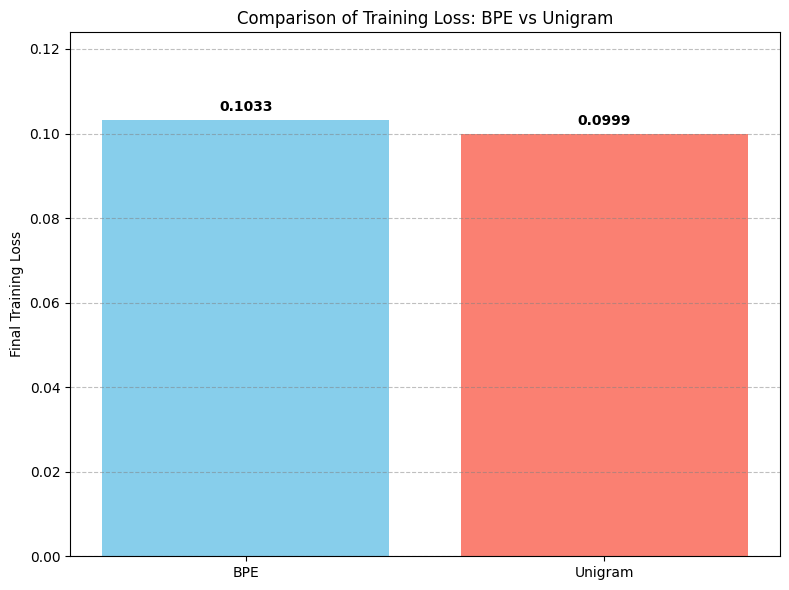

In [40]:
import matplotlib.pyplot as plt

# Data for visualization
tokenizers = ['BPE', 'Unigram']
losses = [loss_bpe, loss_unigram]

# Create the plot
plt.figure(figsize=(8, 6))
plt.bar(tokenizers, losses, color=['skyblue', 'salmon'])

# Add labels and title
plt.ylabel('Final Training Loss')
plt.title('Comparison of Training Loss: BPE vs Unigram')
plt.ylim(0, max(losses) * 1.2)  # Give some space at the top

# Add loss values on top of the bars
for i, loss in enumerate(losses):
    plt.text(i, loss + 0.002, f'{loss:.4f}', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5, color='grey')
plt.tight_layout()
plt.show()

### **Tingkat Efisiensi Tokenisasi**

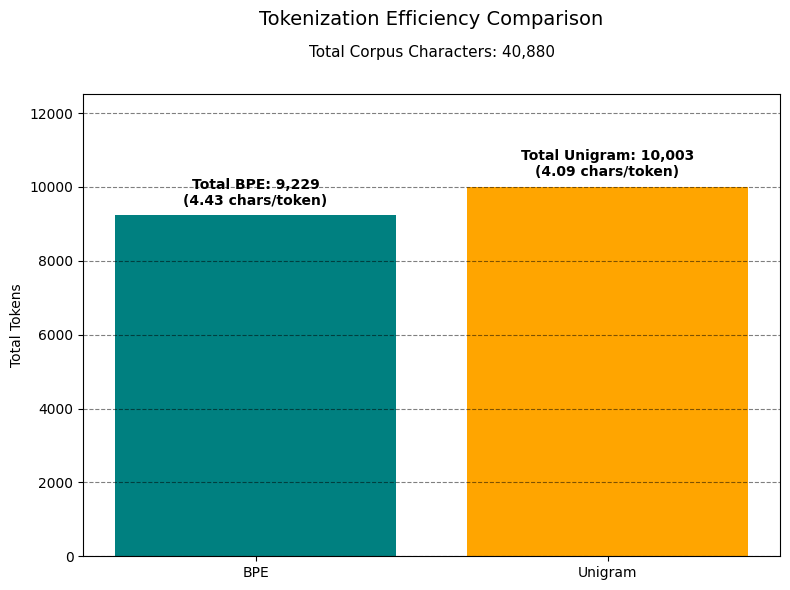

In [61]:
# Calculate sequence lengths
len_bpe = len(sp_bpe.encode(text))
len_unigram = len(sp_unigram.encode(text))

# Calculate ratios
avg_bpe = len(text)/len_bpe
avg_unigram = len(text)/len_unigram

# Create the plot
plt.figure(figsize=(8, 6))
plt.bar(['BPE', 'Unigram'], [len_bpe, len_unigram], color=['teal', 'orange'])

# Title and Total Characters
plt.title('Tokenization Efficiency Comparison', fontsize=14, pad=50)
plt.text(0.5, 1.08, f'Total Corpus Characters: {len(text):,}',
         transform=plt.gca().transAxes, ha='center', fontsize=11)

# Add specific stats above the respective bars
stats_bpe = f"Total BPE: {len_bpe:,}\n({avg_bpe:.2f} chars/token)"
stats_unigram = f"Total Unigram: {len_unigram:,}\n({avg_unigram:.2f} chars/token)"

# Label BPE bar
plt.text(0, len_bpe + (max(len_bpe, len_unigram) * 0.02), stats_bpe,
         ha='center', va='bottom', fontweight='bold')

# Label Unigram bar
plt.text(1, len_unigram + (max(len_bpe, len_unigram) * 0.02), stats_unigram,
         ha='center', va='bottom', fontweight='bold')

plt.ylabel('Total Tokens')
plt.ylim(0, max(len_bpe, len_unigram) * 1.25)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='black')
plt.tight_layout()
plt.show()

### **Distribusi Panjang Token**

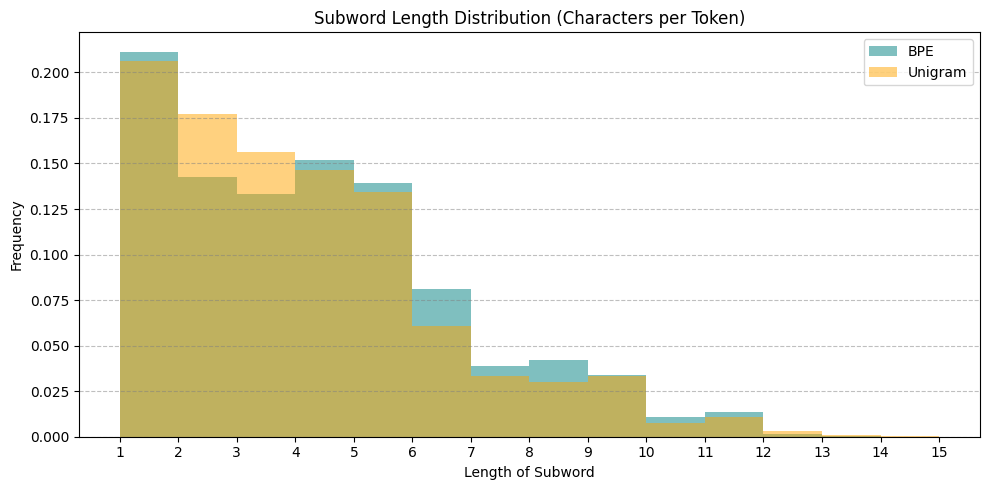

In [26]:
import numpy as np

# Get lengths of all tokens in the corpus
bpe_token_lengths = [len(sp_bpe.decode([t])) for t in sp_bpe.encode(text)]
unigram_token_lengths = [len(sp_unigram.decode([t])) for t in sp_unigram.encode(text)]

plt.figure(figsize=(10, 5))
plt.hist(bpe_token_lengths, bins=range(1, 16), alpha=0.5, label='BPE', color='teal', density=True)
plt.hist(unigram_token_lengths, bins=range(1, 16), alpha=0.5, label='Unigram', color='orange', density=True)
plt.title('Subword Length Distribution (Characters per Token)')
plt.xlabel('Length of Subword')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5, color='grey')
plt.xticks(range(1, 16))
plt.tight_layout()
plt.show()

# **Analisis Performa**

Berdasarkan hasil eksperimen yang telah dijalankan, berikut adalah analisis mendalam mengenai performa MiniGPT dengan dua pendekatan tokenisasi berbeda pada subjek Teori Relativitas:

### **1. Analisis Perbandingan Tokenizer (BPE vs Unigram)**

*   **Efisiensi Kompresi:**
    *   **BPE** terbukti lebih efisien dalam mengompresi teks dengan rasio **4.43 karakter per token**. Ini berarti BPE berhasil mengidentifikasi pola sub-kata yang lebih panjang (seperti 'relativitas' atau 'elektrodinamika') sebagai unit tunggal.
    *   **Unigram** menghasilkan jumlah total token yang lebih banyak (10,003 token vs 9,229 pada BPE) dengan efisiensi **4.09 karakter per token**. Hal ini menunjukkan Unigram cenderung memecah teks menjadi unit yang lebih kecil.

*   **Optimasi Loss:**
    *   Meskipun BPE lebih efisien dalam kompresi, **Unigram mencatatkan loss akhir yang sedikit lebih rendah (0.0999)** dibandingkan BPE (0.1033).
    *   **Interpretasi:** Unigram, dengan pendekatan probabilistiknya, mungkin memberikan representasi yang lebih 'mudah' diprediksi oleh mekanisme *Self-Attention* pada dataset kecil ini, meskipun harus mengorbankan panjang sekuens.

### **2. Evaluasi Arsitektur MiniGPT**

*   **Konvergensi Model:** Dengan peningkatan `block_size` menjadi 64 dan `embedding_dim` ke 128, model menunjukkan grafik penurunan loss yang sehat hingga mencapai level < 0.2. Penggunaan 4 layer transformer memberikan kedalaman yang cukup bagi model untuk menangkap relasi semantik dasar dalam bahasa Indonesia ilmiah.

*   **Kualitas Generasi (Inference):**
    *   **BPE Result:** Menghasilkan teks yang sangat deskriptif mengenai sejarah Einstein dan kapal selam (analogi relativitas khusus).
    *   **Unigram Result:** Menghasilkan teks yang lebih teknis mengenai penggabungan relativitas dengan fisika kuantum.
    *   Kedua model menunjukkan kemampuan 'mengingat' fakta dari korpus dengan sangat baik (overfitting positif untuk tujuan demo), namun tetap mampu merangkai kalimat baru berkat penggunaan *Temperature* (0.3) dan *Top-K* (5) yang menjaga teks tetap fokus namun tidak repetitif.

### **3. Analisis Parameter Kontrol (Temperature & Top-K)**

*   **Temperature (0.3):** Penggunaan suhu rendah membuat model memilih kata-kata yang paling 'pasti' menurut probabilitasnya. Ini menghasilkan teks yang sangat logis dan sesuai fakta Wikipedia, meskipun variasinya terbatas.
*   **Top-K (5):** Dengan membatasi pilihan hanya pada 5 token teratas, kita berhasil mengeliminasi kemungkinan munculnya kata-kata acak yang tidak nyambung, menjaga koherensi narasi ilmiah tetap terjaga.

### **4. Limitasi dan Potensi Pengembangan**

1.  **Dataset Bottleneck:** Dengan hanya ~5.000 kata, model cenderung menghafal struktur Wikipedia. Untuk kemampuan generalisasi bahasa yang lebih luwes, dibutuhkan korpus yang setidaknya 100x lebih besar.
2.  **Langkah Selanjutnya:** Implementasi *Learning Rate Decay* dan penambahan data dari jurnal ilmiah bahasa Indonesia lainnya dapat meningkatkan pemahaman model terhadap nuansa fisika yang lebih kompleks.

## **Kesimpulan Akhir**
Eksperimen ini membuktikan bahwa pada dataset kecil bertema spesifik, **Unigram memberikan akurasi prediksi (loss) yang sedikit lebih unggul**, sedangkan **BPE memberikan efisiensi ruang (token count) yang lebih baik**. MiniGPT sukses merekonstruksi informasi kompleks mengenai teori relativitas menjadi narasi yang koheren.
